# Is openness before take-off brokerage or churn?

**RQ1 deepen (iteration 3), CPU only.** Before a scientific concept "takes off" (sustained uptake, label **E_up**), is its
co-word neighbourhood *open* (low triadic **closure**)? If so, is that openness **Burt-style brokerage**, where the concept
bridges otherwise separate groups, or just **turnover/churn**, where the neighbours keep changing?

The artifact's `method.py` runs a 10-step pipeline (vendored iteration-2 code, pre-registration, population rules,
re-attachment of 426 concepts to co-word snapshots, indicators, labels, event study, verdict, power, prediction,
freeze). That pipeline needs roughly 30 MB of snapshot and parquet intermediates and about 10 minutes on 4 CPUs. This
notebook keeps the orchestrator as-is for reference and **re-runs the analytical core, steps 6 and 7, on a curated
subset**:

* **Step 6, matched event study** (`src/event3.py` + vendored `analysis_event.py`). Each treated concept (first E_up onset
  `t0`) is matched 1:3 to never-emerging concepts with the same founding band × origin field and log-volume at `t0` within
  ±20% (widened to ±30%). The statistic is `S` = the mean over k = -3..0 of the treated-minus-control difference,
  with a treated-level bootstrap CI.
* The openness rows are: raw `closure`; **R1a** `closure_resT` (closure residualised on turnover covariates); **R1b**
  `closure_persist` (closure among persistent neighbours); **R1c** Burt `constraint`, effective size, and `xc_excess`
  (cross-community pair excess); and **R1d** hub-not-clique.
* **Step 7, mechanical verdict** (`src/verdict.py`): BROKERAGE / TURNOVER / MIXED, decided by the pre-registered rule.

The data subset holds all 68 treated concepts, the 27 never-emerging concepts the full run matched to them, and 5 other
never-emerging concepts. The matcher therefore picks the same controls it picked in the full run, so the primary `S`
values reproduce the full run.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, networkx, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'networkx==3.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import os

os.environ.setdefault("OMP_NUM_THREADS", "1")

import argparse  # noqa: E402
import subprocess  # noqa: E402
import sys  # noqa: E402
import time  # noqa: E402
from pathlib import Path  # noqa: E402

from loguru import logger  # noqa: E402

# --- imports of the modules this notebook inlines (src/event3.py, src/verdict.py, src/openness.py, vendor/*) ---
import hashlib
import json
import math
import warnings
from types import SimpleNamespace

import numpy as np
import pandas as pd
import scipy.sparse as sp

# --- notebook-only (visualisation, reference check for Burt metrics) ---
import networkx as nx
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-3/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("examples:", len(data["datasets"][0]["examples"]))

Curated subset of the RQ1 iteration-3 screen fold: 100 MAIN concepts = all 68 E_up-emerging (treated) concepts + the 27 never-emerging concepts the full run matched as controls + 5 further never-emerging concepts. Per concept: frozen population / label fields and concept-year indicators for 2002-2015.
examples: 100


## Configuration

The only knobs that change runtime are the bootstrap draw counts. The original run uses **B = 2,000** for both the
primary cell and the non-primary grid cells (`SPEC3["bootstrap"]`, `SPEC3["bootstrap_nonprimary"]`). The event study
reuses the original seeds (`stable_seed(indicator, cell, 20261001)`), so with B = 2,000 the bootstrap CIs also reproduce
the full run draw-for-draw. With smaller B, the point estimates `S` are unchanged and only the CIs move.

The original grid runs over populations {MAIN, STRICT, SENS} × subsets {all, old, new} × labels {E_up, E_alt, E} ×
routes {all, B_only}. The demo subset holds MAIN screen concepts only, so the grid is restricted to the MAIN × E_up cells
the verdict flags read.

In [5]:
BOOTSTRAP = 2000            # primary-cell bootstrap draws (original: 2000; ~5 s)
BOOTSTRAP_NONPRIMARY = 2000 # grid-cell bootstrap draws   (original: 2000; ~15 s). Lower both for a quicker look.
GRID_POPS = ["MAIN"]            # original: ("MAIN", "STRICT", "SENS")
GRID_SUBSETS = ["all", "old", "new"]
GRID_LABELS = ["E_up"]          # original: ("E_up", "E_alt", "E")
GRID_ROUTES = ["all", "B_only"]
N_BURT_CHECK_GRAPHS = 50        # random ego graphs for the Burt-vs-networkx check (original unit test: 50)

## The original orchestrator (`method.py`)

This is `method.py` as it ships. Each step is a module in `src/` that runs as a subprocess. It is **not called here**,
because steps 0–5 need the iteration-2 co-word snapshots and dataset_5 c-papers, which are not part of the demo data. The
next cells inline steps 6–7 instead. The only edit: the `sys.path` / `import common as K` lines are commented out (the
notebook defines `K` itself below), and the `if __name__ == "__main__": main()` call is replaced by a printout of the
step list.

In [6]:
# ROOT = Path(__file__).resolve().parent
# sys.path.insert(0, str(ROOT / "src"))
# import common as K  # noqa: E402


def sub(args: list[str]) -> None:
    """Run a step as a subprocess (keeps the parent free of large objects; spawn pools inside)."""
    t0 = time.time()
    r = subprocess.run([sys.executable] + args, cwd=ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"step {' '.join(args)} failed with code {r.returncode}")
    logger.info(f"step {' '.join(args)} done in {time.time() - t0:.0f}s")


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", type=int, default=0)
    ap.add_argument("--workers", type=int, default=min(4, K.detect_cpus()))
    a = ap.parse_args()
    K.setup_logging("method")
    K.set_ram_limit(26)
    t0 = time.time()
    w = str(a.workers)
    steps = [
        (0, ["src/setup.py"]),
        (1, ["src/population.py"]),
        (2, ["src/prep3.py"]),
        (3, ["src/attach.py", "--modes", "full", "repro_code", "repro_data", "--workers", w]),
        (4, ["src/indicators3.py", "--modes", "repro_code", "repro_data", "full", "--workers", w]),
        (4, ["src/repro.py"]),
        (4, ["src/attach.py", "--modes", "sealed", "--years"] + [str(y) for y in range(2000, K.SPEC3["sealed_max_year"] + 1)]
         + ["--workers", w]),
        (4, ["src/indicators3.py", "--modes", "sealed", "--workers", w]),
        (5, ["src/labels3.py"]),
        (5, ["src/leakage.py"]),
        (6, ["src/event3.py"]),
        (7, ["src/verdict.py"]),
        (8, ["src/power.py"]),
        (9, ["src/predict3.py"]),
        (10, ["src/figs.py"]),
        (10, ["src/audit.py"]),
        (10, ["confirm_heldout.py", "--self-test-on-screen"]),
        (10, ["src/exports.py"]),
        (10, ["src/freeze.py"]),
    ]
    for k, args in steps:
        if k >= a.start:
            sub(args)
    logger.info(f"pipeline done in {time.time() - t0:.0f}s")


# if __name__ == "__main__":
#     main()
print("Pipeline steps (method.py): 0 setup | 1 population | 2 prep3 | 3 attach | 4 indicators3 + repro gate + sealed pass |"
      " 5 labels3 + leakage | 6 event3 | 7 verdict | 8 power | 9 predict3 | 10 figs, audit, confirm self-test, exports, freeze")
print("This notebook re-runs steps 6 (event3) and 7 (verdict) below.")

Pipeline steps (method.py): 0 setup | 1 population | 2 prep3 | 3 attach | 4 indicators3 + repro gate + sealed pass | 5 labels3 + leakage | 6 event3 | 7 verdict | 8 power | 9 predict3 | 10 figs, audit, confirm self-test, exports, freeze
This notebook re-runs steps 6 (event3) and 7 (verdict) below.


## Frozen specifications (`vendor/config.py` SPEC, `src/common.py` SPEC3)

`SPEC` is the iteration-2 spec, vendored byte-identical. Only the keys steps 6–7 read are copied here: the matching rule,
the event-time window and the sealed years. `SPEC3` is the iteration-3 spec, pre-registered (hashed into
`prereg_v3.json`) **before any label was computed**. It holds the verdict rule text, the primary Holm family and the
seeds. The only edit is that the two bootstrap counts come from the config cell.

`K`, `C`, `AE` and `lm` are small namespaces standing in for the modules `common`, `config`, `analysis_event` and
`lib_metrics`, so the copied function bodies run unchanged.

In [7]:
# ---------------- vendor/config.py (subset of SPEC used by steps 6-7; values verbatim)
SPEC: dict = dict(
    E_uptake_mean=20, E_max_fall=0.30, E_pct_gain=20, ages=[3, 8], t_max=2019,
    sealed_focal_years=[2016, 2017, 2018], screen_onset_years=list(range(2008, 2016)),
    match=dict(band=True, origin_group=True, vol_caliper=0.20, widen=0.30, ratio=3, replace=True),
    bootstrap=1000,
    es_rel_years=list(range(-5, 1)), es_summary_window=[-3, 0],
)
SEALED_IDS: set[str] = set()   # the held-out fold is sealed and not part of the demo data


def assert_not_sealed(concept_ids, focal_years=()) -> None:
    """Code guard: held-out concepts and sealed focal years never enter E/W2 computations."""
    bad = set(concept_ids) & SEALED_IDS
    if bad:
        raise RuntimeError(f"SEALED concept ids requested: {sorted(bad)[:5]}")
    bad_t = set(int(t) for t in focal_years) & set(SPEC["sealed_focal_years"])
    if bad_t:
        raise RuntimeError(f"SEALED focal years requested: {sorted(bad_t)}")


# ---------------- src/common.py SPEC3 (frozen before any label; verbatim except the bootstrap counts)
VERDICT_RULES = (
    "BROKERAGE if ALL of: S_res < 0 and CI_res excludes 0; |S_res| >= 0.5*|S_raw|; S(closure_persist) < 0; "
    "S(constraint) < 0; (CI(closure_persist) excludes 0 OR CI(constraint) excludes 0). "
    "TURNOVER if ALL of: CI_res includes 0; |S_res| < 0.5*|S_raw|; R1b null (CI(closure_persist) includes 0). "
    "MIXED otherwise. R1b NON-ESTIMABLE (< 10 matched treated with finite closure_persist in k=-3..0) counts as null "
    "for TURNOVER and as failing for BROKERAGE. S_raw = S(closure), S_res = S(closure_resT), cell = MAIN x all x E_up "
    "x route all. Flags never change the label: R1c_degree_driven, R1b_selection, H_sensitive, underpowered, "
    "fresh_replication, route_B_only agreement, R1a_model_dependent."
)
SPEC3: dict = dict(
    bootstrap=BOOTSTRAP, bootstrap_nonprimary=BOOTSTRAP_NONPRIMARY, es_primary_window=[-3, 0], es_sens_window=[-5, -1],
    es_rel_years=list(range(-5, 1)), persist_min=5, xcomm_null_draws=50, xcomm_strength_deciles=10,
    ego_min_neighbours=5, xc_min_members=5,
    r1a_covariates=["new_relation_rate", "novelty", "beta_sim_rar", "log_vol3", "age", "H"],
    r1a_na_rule="mean-fill (screen fit-set mean) + NA dummy for any covariate with missing values "
                "(beta_sim_rar and H by declaration; novelty / new_relation_rate if NA occurs)",
    r1a_fit_set="arm main, fold screen, finite closure, age >= -2 (all years); NO label column in scope",
    r1a_sensitivities={"closure_resT_cc": "complete-case (no fill, no dummies)",
                       "closure_resT_raw": "beta_sim_raw replaces beta_sim_rar (mean-fill + NA dummy)"},
    holm_primary=["closure_resT", "closure_persist", "constraint"],
    screened_direction={"closure": "-", "closure_resT": "-", "closure_persist": "-", "constraint": "-",
                        "xc_excess": "+", "effsize": "+", "wmz": "+"},
    verdict_rules=VERDICT_RULES,
    r1b_min_treated=10, r1b_selection_points=15, h_sensitive_loss=0.5, underpowered_n=30,
    match_H_sensitivity_caliper_sd=0.25,
    betweenness_seed_base=20260928, betweenness_pivots=500,
    sealed_max_year=2015,
    seeds=dict(es=20261001, panel=7, cv=11, sim=13, xc="XC"),
)

S = SPEC   # vendored analysis_event.py uses the module-level alias S = C.SPEC
C = SimpleNamespace(SPEC=SPEC, SEALED_IDS=SEALED_IDS, assert_not_sealed=assert_not_sealed)
K = SimpleNamespace(SPEC3=SPEC3)
print("SPEC3 bootstrap:", SPEC3["bootstrap"], "| non-primary:", SPEC3["bootstrap_nonprimary"])

SPEC3 bootstrap: 2000 | non-primary: 2000


## Data → the two tables step 6 reads

In the original run, `event3.main()` reads `results/indicators/concept_year_indicators_hydrated.parquet` (`ind`, one
row per concept-year) and `results/labels/labels_screen.parquet` (`lab`, one row per concept × focal year t). Every
field step 6 reads from `lab` is constant per concept (population flags, founding band, origin field, route, old/new
arm, E_up group and onset), so the demo data stores one record per concept. This cell rebuilds both tables from the
loaded JSON; it replaces the two `pd.read_parquet` calls.

In [8]:
ex = data["datasets"][0]["examples"]
lab = pd.DataFrame([e["concept"] for e in ex])
ind_rows = []
for e in ex:
    ser = e["indicators"]
    for i, y in enumerate(ser["year"]):
        row = {"concept_id": e["concept"]["concept_id"], "year": int(y), "fold": e["fold"],
               "F_band": e["concept"]["F_band"], "origin_group": e["concept"]["origin_group"],
               "old_new": e["concept"]["old_new"]}
        for c, vals in ser.items():
            if c != "year":
                row[c] = np.nan if vals[i] is None else vals[i]
        ind_rows.append(row)
ind = pd.DataFrame(ind_rows)
for c in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess"):
    ind[c] = ind[c].astype(float)
print("lab:", lab.shape, "| ind:", ind.shape)
print(lab.groupby(["group_E_up", "old_new"]).size().rename("n_concepts").to_string())
print(pd.Series([e["role"] for e in ex]).value_counts().to_string())
lab.head()

lab: (100, 15) | ind: (942, 30)
group_E_up  old_new
emerging    new        35
            old        33
never       new        14
            old        18
treated            68
matched_control    27
never_extra         5


,concept_id,F,F_band,origin_group,MAIN,STRICT,SENS,old_new,route,group_E_up,onset_E_up,group_E_alt,onset_E_alt,group_E,onset_E
0,c_007a7950eb4d,2007,2005-07,F26:Mathematics,True,True,True,old,B_s2_index,emerging,2010.0,never,NaN,never,NaN
1,c_015399b04dea,2010,2008-11,F31:Physics and Astronomy,True,True,True,new,B_s2_index,emerging,2013.0,never,NaN,never,NaN
2,c_02792d2208de,2010,2008-11,F17:Computer Science,True,True,True,old,B_s2_index,emerging,2013.0,never,NaN,never,NaN
3,c_03828aedf823,2006,2005-07,F31:Physics and Astronomy,True,True,True,old,B_s2_index,emerging,2013.0,emerging,2013.0,never,NaN
4,c_05ffe8df405c,2009,2008-11,F25:Materials Science,True,True,True,new,A_openalex_native,emerging,2012.0,never,NaN,never,NaN


## Vendored helpers: `lib_metrics.py` (seeds, SMD, Holm)

These are copied byte-for-byte from the vendored iteration-2 `lib_metrics.py`. `stable_seed` is a SHA-1-based seed that
does not depend on `PYTHONHASHSEED`. Every bootstrap in the event study is seeded with `stable_seed(indicator, cell,
20261001)`.

In [9]:
def stable_seed(*parts: object) -> int:
    """Deterministic 32-bit seed from arbitrary parts (independent of PYTHONHASHSEED)."""
    h = hashlib.sha1("|".join(map(str, parts)).encode()).hexdigest()
    return int(h[:8], 16)


def smd(a, b) -> float:
    """Standardised mean difference with pooled SD."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if a.size < 2 or b.size < 2:
        return math.nan
    sd = math.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2.0)
    if sd == 0:
        return 0.0
    return float((a.mean() - b.mean()) / sd)


def holm(pvals) -> list[float]:
    """Holm step-down adjusted p-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


lm = SimpleNamespace(stable_seed=stable_seed, smd=smd, holm=holm)

## Vendored matcher and event-study matrix (`analysis_event.py`)

* `match`: for each treated concept with onset `t0`, the candidates are never-emerging concepts in the same founding
  band and origin group with positive 3-year volume at `t0`. It keeps the 3 nearest in |log vol3| within a ±20% volume
  caliper, widening to ±30% if none qualify. Matching is with replacement.
* `es_matrix`: builds the treated × relative-year matrix of (treated value − mean of its matched controls) for
  k = −5..0.
* `es_stats`: the vendored bootstrap. Step 6 checks that its own `es_boot` returns exactly this S and CI.
* `balance`: standardised mean differences before and after matching. The single notebook edit is that the
  `log_strength` row is skipped, because raw node strength is not in the demo data.

In [10]:
def match(lab: pd.DataFrame, ind: pd.DataFrame, rng_seed: int = 0, band: bool = True, origin: bool = True,
          caliper: float = S["match"]["vol_caliper"], widen: float = S["match"]["widen"],
          treated_onsets: dict | None = None, never_set: set | None = None, exclude_self: bool = False) -> pd.DataFrame:
    """1:ratio nearest-neighbour matching (with replacement) on log vol3 at t0 within band x origin group."""
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    onsets = treated_onsets if treated_onsets is not None else lab[lab.group == "emerging"].drop_duplicates("concept_id") \
        .set_index("concept_id").onset.astype(int).to_dict()
    never = never_set if never_set is not None else set(lab.loc[lab.group == "never", "concept_id"])
    out = []
    for c, t0 in onsets.items():
        v = vol3.get((c, t0), 0)
        cands = [n for n in never if (not band or info.loc[n, "F_band"] == info.loc[c, "F_band"])
                 and (not origin or info.loc[n, "origin_group"] == info.loc[c, "origin_group"])
                 and (not exclude_self or n != c) and vol3.get((n, t0), 0) > 0]
        chosen, widened = [], False
        for cal in (caliper, widen):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands
                  if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == widen
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened,
                        vol3_t0=v))
    return pd.DataFrame(out)


def balance(m: pd.DataFrame, ind: pd.DataFrame, lab: pd.DataFrame) -> list:
    val = ind.set_index(["concept_id", "year"])
    covs = {"log_vol3": "log_vol3", "age": "age", "log_strength": None, "H": "H"}
    never = sorted(set(lab.loc[lab.group == "never", "concept_id"]))
    rows = []
    for name, col in covs.items():
        if col is None and "strength" not in val.columns:   # notebook: raw strength is not in the demo data
            continue
        def g(c, y):
            try:
                x = val.loc[(c, y)]
            except KeyError:
                return np.nan
            return math.log1p(x["strength"]) if col is None else x[col]
        tr = [g(r.concept_id, r.t0) for r in m.itertuples()]
        before = [g(n, r.t0) for r in m.itertuples() for n in never]
        after = [np.nanmean([g(n, r.t0) for n in r.controls]) if r.controls else np.nan for r in m.itertuples()]
        trm = [a for a, r in zip(tr, m.itertuples()) if r.controls]
        after = [a for a in after if np.isfinite(a)]
        rows.append(dict(covariate=name, smd_before=lm.smd(tr, before), smd_after=lm.smd(trm, after),
                         mean_treated=float(np.nanmean(tr)) if tr else np.nan,
                         mean_controls_after=float(np.nanmean(after)) if after else np.nan))
    return rows


def es_matrix(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> tuple[np.ndarray, list]:
    """Per-treated x relative-year difference matrix (treated - mean of matched controls)."""
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    ks = S["es_rel_years"]
    mm = m[m.n_controls > 0]
    M = np.full((len(mm), len(ks)), np.nan)
    contrib = []
    for i, r in enumerate(mm.itertuples()):
        for j, k in enumerate(ks):
            y = r.t0 + k
            tv = val.get((r.concept_id, y), np.nan)
            cv = np.array([val.get((n, y), np.nan) for n in r.controls], dtype=float)
            cm = float(np.nanmean(cv)) if np.isfinite(cv).any() else np.nan
            if np.isfinite(tv) and np.isfinite(cm):
                M[i, j] = tv - cm
            contrib.append(dict(concept_id=r.concept_id, t0=r.t0, k=k, indicator=col, treated=tv, control_mean=cm,
                                controls="|".join(r.controls)))
    return M, contrib


def es_stats(M: np.ndarray, B: int, seed: int) -> dict:
    ks = S["es_rel_years"]
    lo, hi = S["es_summary_window"]
    wk = [j for j, k in enumerate(ks) if lo <= k <= hi]
    with np.errstate(all="ignore"):
        import warnings
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        Sp = float(np.nanmean(diff[wk])) if np.isfinite(diff[wk]).any() else np.nan
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = np.full(B, np.nan)
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                bS[b] = np.nanmean(d[wk]) if np.isfinite(d[wk]).any() else np.nan
    ok = np.isfinite(bS)
    if ok.sum() < 10:
        return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).tolist(), S=Sp, ci=[np.nan, np.nan], se=np.nan,
                    p=np.nan, ci_k=[[np.nan, np.nan]] * len(ks), n_treated=len(M))
    ci = np.percentile(bS[ok], [2.5, 97.5]).tolist()
    p = 2 * min(np.mean(bS[ok] <= 0), np.mean(bS[ok] >= 0))
    p = float(max(p, 1.0 / ok.sum()))
    ci_k = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
            for j in range(len(ks))]
    return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist(), S=Sp, ci=ci,
                se=float(np.nanstd(bS[ok], ddof=1)), p=min(1.0, p), ci_k=ci_k, n_treated=len(M))


AE = SimpleNamespace(match=match, balance=balance, es_matrix=es_matrix, es_stats=es_stats)

## Step 6 machinery (`src/event3.py`)

* `es_boot` repeats the vendored `es_stats` bootstrap draw-for-draw (same RNG calls) and adds the −5..−1 sensitivity
  window and one-sided p-values.
* `cell_sets` / `run_cell` pick treated onsets and never-emerging controls for a (population, old/new subset, label,
  route) cell, match them, and compute S for every indicator row.
* `match_H` is the vendored matcher with an extra |H diff| caliper, used for the H-matched sensitivity.
* `na_share_by_k` checks whether R1b (`closure_persist`) is missing more often for treated than for controls, which
  would indicate selection.

This is copied from `src/event3.py`. The only edits: the in-function `import analysis_event as AE` /
`import lib_metrics as lm` lines are removed (the namespaces above replace them).

In [11]:
ROWS_PRIMARY = ["closure_resT", "closure_persist", "constraint"]
ROWS = ["closure", "closure_resT", "closure_resT_cc", "closure_resT_raw", "closure_persist", "constraint", "cdeg_diag",
        "effsize", "efficiency", "xc_excess", "xc_obs", "wmz", "d_wmz", "d_closure", "new_relation_rate", "novelty",
        "beta_sim_rar", "log_vol3", "pct", "closure_res", "constraint_res", "xc_excess_res", "closure_persist_res",
        "n_ego", "persist_overlap"]
ROWS_GRID = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "wmz", "d_wmz",
             "d_closure", "new_relation_rate", "novelty"]
DIRECTION = {"closure": -1, "closure_resT": -1, "closure_resT_cc": -1, "closure_resT_raw": -1, "closure_persist": -1,
             "constraint": -1, "cdeg_diag": -1, "closure_res": -1, "constraint_res": -1, "closure_persist_res": -1,
             "xc_excess": 1, "xc_excess_res": 1, "xc_obs": 1, "effsize": 1, "efficiency": 1, "wmz": 1, "d_wmz": 1,
             "d_closure": -1}


# ----------------------------------------------------------------------------- bootstrap (vendored draw order)
def es_boot(M: np.ndarray, B: int, seed: int, windows: dict | None = None) -> dict:
    ks = K.SPEC3["es_rel_years"]
    windows = windows or {"primary": tuple(K.SPEC3["es_primary_window"]), "sens": tuple(K.SPEC3["es_sens_window"])}
    wk = {n: [j for j, k in enumerate(ks) if lo <= k <= hi] for n, (lo, hi) in windows.items()}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        S = {n: (float(np.nanmean(diff[w])) if np.isfinite(diff[w]).any() else np.nan) for n, w in wk.items()}
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = {n: np.full(B, np.nan) for n in wk}
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                for n, w in wk.items():
                    bS[n][b] = np.nanmean(d[w]) if np.isfinite(d[w]).any() else np.nan
    out = dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist() if len(M) else [0] * len(ks),
               n_treated=int(len(M)))
    for n in wk:
        x = bS[n][np.isfinite(bS[n])]
        if len(x) < 10:
            out[n] = dict(S=S[n], ci=[np.nan, np.nan], se=np.nan, p=np.nan, p_one_neg=np.nan, p_one_pos=np.nan,
                          ci90=[np.nan, np.nan])
            continue
        p = float(max(2 * min(np.mean(x <= 0), np.mean(x >= 0)), 1.0 / len(x)))
        out[n] = dict(S=S[n], ci=np.percentile(x, [2.5, 97.5]).tolist(), ci90=np.percentile(x, [5, 95]).tolist(),
                      se=float(np.std(x, ddof=1)), p=min(1.0, p),
                      p_one_neg=float(max(np.mean(x >= 0), 1.0 / len(x))),   # H1: S < 0
                      p_one_pos=float(max(np.mean(x <= 0), 1.0 / len(x))))   # H1: S > 0
    out["ci_k"] = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
                   for j in range(len(ks))]
    return out


def seed_for(col: str, cell: str = "") -> int:
    return lm.stable_seed(col, cell, K.SPEC3["seeds"]["es"]) % 2 ** 31


# ----------------------------------------------------------------------------- cell machinery
def cell_sets(lab: pd.DataFrame, P: str, subset: str, label: str, route: str, new_controls: str = "all") -> tuple[dict, set, pd.DataFrame]:
    d = lab[lab[P].astype(bool)]
    if route == "B_only":
        d = d[d.route == "B_s2_index"]
    per = d.drop_duplicates("concept_id").set_index("concept_id")
    g, on = per[f"group_{label}"], per[f"onset_{label}"]
    never = set(per.index[g == "never"])
    if subset == "new" and new_controls == "new_only":
        never = {c for c in never if per.loc[c, "old_new"] == "new"}
    tr = per[(g == "emerging")]
    if subset in ("old", "new"):
        tr = tr[tr.old_new == subset]
    onsets = {c: int(on[c]) for c in tr.index}
    lab_c = d.copy()
    lab_c["group"] = lab_c[f"group_{label}"]
    lab_c["onset"] = lab_c[f"onset_{label}"]
    return onsets, never, lab_c


def run_cell(lab: pd.DataFrame, ind: pd.DataFrame, P: str, subset: str, label: str, route: str, rows: list[str], B: int,
             new_controls: str = "all", match_fn=None) -> dict:
    onsets, never, lab_c = cell_sets(lab, P, subset, label, route, new_controls)
    cell = f"{P}|{subset}|{label}|{route}" + ("|newctl" if new_controls != "all" else "")
    if not onsets:
        return dict(cell=cell, n_onsets=0, n_matched=0, rows={}, m=None)
    m = (match_fn or AE.match)(lab_c, ind, treated_onsets=onsets, never_set=never)
    mm = m[m.n_controls > 0]
    res = dict(cell=cell, n_onsets=len(m), n_matched=int(len(mm)), match_rate=float(len(mm) / len(m)),
               widened_share=float(mm.widened.mean()) if len(mm) else np.nan, n_never=len(never),
               n_unique_controls=len({c for cs in mm.controls for c in cs}), rows={}, m=m, contrib=[])
    for col in rows:
        if col not in ind.columns:
            continue
        M, contrib = AE.es_matrix(m, ind, col)
        st = es_boot(M, B, seed_for(col, cell))
        st["direction"] = DIRECTION.get(col, 0)
        res["rows"][col] = st
        res["contrib"] += contrib
    return res


def balance_ext(m: pd.DataFrame, ind: pd.DataFrame, lab_c: pd.DataFrame) -> list:
    rows = AE.balance(m, ind, lab_c)
    val = ind.set_index(["concept_id", "year"])
    route = lab_c.drop_duplicates("concept_id").set_index("concept_id").route
    never = sorted(set(lab_c.loc[lab_c.group == "never", "concept_id"]))
    mm = m[m.n_controls > 0]

    def g(c, y, col):
        try:
            return float(val.loc[(c, y), col])
        except KeyError:
            return np.nan
    for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess", "new_relation_rate", "novelty",
                "beta_sim_rar", "wmz", "n_ego"):
        tr = [g(r.concept_id, r.t0, col) for r in mm.itertuples()]
        before = [g(n, r.t0, col) for r in mm.itertuples() for n in never]
        after = [np.nanmean([g(n, r.t0, col) for n in r.controls]) for r in mm.itertuples()]
        rows.append(dict(covariate=f"{col}@t0", smd_before=lm.smd(tr, before), smd_after=lm.smd(tr, after),
                         mean_treated=float(np.nanmean(tr)) if len(tr) else np.nan,
                         mean_controls_after=float(np.nanmean(after)) if len(after) else np.nan))
    rb_t = [float(route[c] == "B_s2_index") for c in mm.concept_id]
    rb_c = [float(np.mean([route[n] == "B_s2_index" for n in r.controls])) for r in mm.itertuples()]
    rows.append(dict(covariate="route_B_share", smd_before=lm.smd(rb_t, [float(route[n] == "B_s2_index") for n in never]),
                     smd_after=lm.smd(rb_t, rb_c), mean_treated=float(np.mean(rb_t)) if rb_t else np.nan,
                     mean_controls_after=float(np.mean(rb_c)) if rb_c else np.nan))
    return rows


def na_share_by_k(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> dict:
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    out = {}
    mm = m[m.n_controls > 0]
    for k in K.SPEC3["es_rel_years"]:
        t = [not np.isfinite(val.get((r.concept_id, r.t0 + k), np.nan)) for r in mm.itertuples()]
        c = [not np.isfinite(val.get((n, r.t0 + k), np.nan)) for r in mm.itertuples() for n in r.controls]
        out[str(k)] = dict(treated_na=float(np.mean(t)) if t else np.nan, control_na=float(np.mean(c)) if c else np.nan)
    win = [k for k in K.SPEC3["es_rel_years"] if K.SPEC3["es_primary_window"][0] <= k <= K.SPEC3["es_primary_window"][1]]
    tw = np.nanmean([out[str(k)]["treated_na"] for k in win])
    cw = np.nanmean([out[str(k)]["control_na"] for k in win])
    n_est = sum(1 for r in mm.itertuples() if any(np.isfinite(val.get((r.concept_id, r.t0 + k), np.nan)) for k in win))
    return dict(by_k=out, window_treated_na=float(tw), window_control_na=float(cw),
                window_na_gap_points=float(100 * (tw - cw)), n_treated_with_finite_in_window=int(n_est))


def match_H(lab: pd.DataFrame, ind: pd.DataFrame, treated_onsets: dict, never_set: set, h_caliper: float) -> pd.DataFrame:
    """Vendored matcher (same band x origin x +-20%/30% vol3 rule, 1:3 with replacement) + |H_t0 diff| <= h_caliper."""
    S = C.SPEC
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    H = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.H)}
    out = []
    for c, t0 in treated_onsets.items():
        v = vol3.get((c, t0), 0)
        h0 = H.get((c, t0), np.nan)
        cands = [n for n in never_set if info.loc[n, "F_band"] == info.loc[c, "F_band"]
                 and info.loc[n, "origin_group"] == info.loc[c, "origin_group"] and vol3.get((n, t0), 0) > 0
                 and np.isfinite(h0) and np.isfinite(H.get((n, t0), np.nan)) and abs(H[(n, t0)] - h0) <= h_caliper]
        chosen, widened = [], False
        for cal in (S["match"]["vol_caliper"], S["match"]["widen"]):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == S["match"]["widen"]
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened, vol3_t0=v))
    return pd.DataFrame(out)


def _flat(res: dict) -> list:
    out = []
    for col, st in res["rows"].items():
        out.append(dict(cell=res["cell"], indicator=col, n_onsets=res["n_onsets"], n_matched=res["n_matched"],
                        match_rate=res.get("match_rate"), S=st["primary"]["S"], ci_lo=st["primary"]["ci"][0],
                        ci_hi=st["primary"]["ci"][1], p=st["primary"]["p"], p_one_neg=st["primary"]["p_one_neg"],
                        p_one_pos=st["primary"]["p_one_pos"], se=st["primary"]["se"],
                        S_sens=st["sens"]["S"], ci_sens_lo=st["sens"]["ci"][0], ci_sens_hi=st["sens"]["ci"][1],
                        n_k=st["n_k"]))
    return out

## Step 6a: the primary cell MAIN × all × E_up × route all

This is the first half of `event3.main()`, unchanged apart from dropping the parquet and JSON writes. It matches
treated to controls, computes S for every row, checks that `es_boot` equals the vendored `es_stats`, applies Holm to
the primary family {R1a, R1b, constraint}, runs the R1b missingness check and computes covariate balance.

In [12]:
t_start = time.time()
B = K.SPEC3["bootstrap"]
C.assert_not_sealed(lab.concept_id)
main_ids = set(lab.loc[lab.MAIN.astype(bool), "concept_id"])
# ---------------- primary cell
prim = run_cell(lab, ind, "MAIN", "all", "E_up", "all", ROWS, B)
_, never_p, lab_p = cell_sets(lab, "MAIN", "all", "E_up", "all")
m = prim["m"]
# assert identity with the vendored es_stats for the primary window (same bootstrap draws)
for col in ("closure", "closure_resT", "constraint"):
    Mv, _ = AE.es_matrix(m, ind, col)
    vs = AE.es_stats(Mv, B, seed_for(col, prim["cell"]))
    mine = prim["rows"][col]["primary"]
    assert (np.isnan(vs["S"]) and np.isnan(mine["S"])) or abs(vs["S"] - mine["S"]) < 1e-12, col
    assert np.allclose(vs["ci"], mine["ci"], equal_nan=True), col
pf_p = [prim["rows"][c]["primary"]["p"] for c in ROWS_PRIMARY]
holm_p = lm.holm(pf_p)
fam = {c: dict(S=prim["rows"][c]["primary"]["S"], ci=prim["rows"][c]["primary"]["ci"], p_two=p, p_holm=h,
               p_one_screened=prim["rows"][c]["primary"]["p_one_neg"], S_sens=prim["rows"][c]["sens"]["S"],
               ci_sens=prim["rows"][c]["sens"]["ci"], n_k=prim["rows"][c]["n_k"])
       for c, p, h in zip(ROWS_PRIMARY, pf_p, holm_p)}
fam["closure_raw_row0"] = dict(S=prim["rows"]["closure"]["primary"]["S"], ci=prim["rows"]["closure"]["primary"]["ci"],
                               p_two=prim["rows"]["closure"]["primary"]["p"],
                               p_one_screened=prim["rows"]["closure"]["primary"]["p_one_neg"])
na_persist = na_share_by_k(m, ind, "closure_persist")
bal = balance_ext(m, ind, lab_p)
primary = dict(cell=prim["cell"], n_onsets=prim["n_onsets"], n_matched=prim["n_matched"], match_rate=prim["match_rate"],
               widened_share=prim["widened_share"], n_never=prim["n_never"], n_unique_controls=prim["n_unique_controls"],
               family=fam, holm_family=ROWS_PRIMARY, rows={k: v for k, v in prim["rows"].items()},
               closure_persist_na=na_persist, balance=bal)
logger.info(f"PRIMARY {prim['cell']}: onsets {prim['n_onsets']} matched {prim['n_matched']}; " +
            "; ".join(f"{c} S={fam[c]['S']:.3f} [{fam[c]['ci'][0]:.3f},{fam[c]['ci'][1]:.3f}] pHolm={fam[c]['p_holm']:.3f}"
                      for c in ROWS_PRIMARY) + f"; raw closure S={fam['closure_raw_row0']['S']:.3f}")
print(f"primary cell done in {time.time() - t_start:.1f}s")
pd.DataFrame(bal)[["covariate", "smd_before", "smd_after", "mean_treated", "mean_controls_after"]].round(3)

20:42:18|INFO   |PRIMARY MAIN|all|E_up|all: onsets 68 matched 26; closure_resT S=-0.295 [-0.663,0.092] pHolm=0.194; closure_persist S=-0.575 [-1.270,0.122] pHolm=0.194; constraint S=0.083 [0.017,0.147] pHolm=0.039; raw closure S=-0.439


primary cell done in 6.7s


,covariate,smd_before,smd_after,mean_treated,mean_controls_after
0,log_vol3,1.346,0.096,4.372,3.949
1,age,0.127,-0.125,3.250,3.583
2,H,0.535,0.554,0.636,0.389
3,closure@t0,-0.067,-0.583,4.528,5.051
4,closure_resT@t0,-0.061,-0.329,0.224,0.495
5,closure_persist@t0,-0.388,-0.640,3.915,5.039
6,constraint@t0,0.312,0.657,0.347,0.208
7,xc_excess@t0,0.139,0.148,-0.340,-0.374
8,new_relation_rate@t0,0.325,1.258,0.333,0.189
9,novelty@t0,0.374,1.232,0.463,0.334


## Step 6b: H-matched sensitivity and the grid cells the verdict reads

The H-matched sensitivity adds a caliper on disciplinary entropy H at `t0` (0.25 SD) to the matcher. The verdict raises
the `H_sensitive` flag if S(R1a) changes sign or loses more than half its size. The sub-cells supply the other flags:
**new** concepts (the fresh replication, since the "new" concepts were never used in iterations 1–2), **old** concepts,
and **route B_only** agreement.

*Demo note:* the demo data holds only the never-emerging concepts the full run matched plus 5 others. The H-matched
matcher, which draws a different set of candidates, therefore sees a smaller pool than the full run. Expect small
differences there, while the primary cell reproduces exactly.

In [13]:
sdH = float(ind.loc[(ind.fold == "screen") & (ind.year <= 2015), "H"].std())
onsets_p, _, _ = cell_sets(lab, "MAIN", "all", "E_up", "all")
mh = match_H(lab_p, ind, onsets_p, never_p, K.SPEC3["match_H_sensitivity_caliper_sd"] * sdH)
hres = {}
for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess"):
    M, _ = AE.es_matrix(mh, ind, col)
    hres[col] = es_boot(M, B, seed_for(col, "Hmatch"))["primary"]
primary["H_matched"] = dict(caliper=K.SPEC3["match_H_sensitivity_caliper_sd"] * sdH, sd_H=sdH,
                            n_matched=int((mh.n_controls > 0).sum()), rows=hres)
primary["n_onsets"], primary["n_matched"] = prim["n_onsets"], prim["n_matched"]

# ---------------- grid (restricted by the config cell)
Bn = K.SPEC3["bootstrap_nonprimary"]
flat = _flat(prim)
grid_meta = []
cells = [(P, s, lb, r) for P in GRID_POPS for s in GRID_SUBSETS for lb in GRID_LABELS for r in GRID_ROUTES]
for P, s, lb, r in cells:
    if (P, s, lb, r) == ("MAIN", "all", "E_up", "all"):
        continue
    res = run_cell(lab, ind, P, s, lb, r, ROWS_GRID, Bn)
    flat += _flat(res)
    grid_meta.append(dict(cell=res["cell"], n_onsets=res["n_onsets"], n_matched=res["n_matched"], match_rate=res.get("match_rate")))
grid = pd.DataFrame(flat)
logger.info(f"grid done: {len(grid)} rows over {grid.cell.nunique()} cells ({time.time() - t_start:.0f}s)")
pd.DataFrame(grid_meta)

20:42:32|INFO   |grid done: 76 rows over 6 cells (21s)


,cell,n_onsets,n_matched,match_rate
0,MAIN|all|E_up|B_only,62,22,0.354839
1,MAIN|old|E_up|all,33,12,0.363636
2,MAIN|old|E_up|B_only,30,10,0.333333
3,MAIN|new|E_up|all,35,14,0.400000
4,MAIN|new|E_up|B_only,32,12,0.375000


## Step 7: mechanical verdict (`src/verdict.py`)

`decide()` is copied verbatim. It applies the pre-registered rule text printed below:

* **BROKERAGE** requires the turnover-residualised R1a to stay significantly negative and keep at least half the raw
  effect, and it requires persistent-neighbour closure (R1b) and Burt constraint to both point towards brokerage.
* **TURNOVER** requires R1a to lose more than half the raw effect, with R1a and R1b both null.
* Anything else is **MIXED**.

The flags are reported but never change the label.

In [14]:
def excl0(ci) -> bool:
    return bool(ci is not None and np.isfinite(ci[0]) and np.isfinite(ci[1]) and (ci[0] > 0 or ci[1] < 0))


def incl0(ci) -> bool:
    return bool(ci is not None and np.isfinite(ci[0]) and np.isfinite(ci[1]) and ci[0] <= 0 <= ci[1])


def grid_row(grid: pd.DataFrame, cell: str, ind: str) -> dict | None:
    r = grid[(grid.cell == cell) & (grid.indicator == ind)]
    return None if r.empty else r.iloc[0].to_dict()


def decide(pf: dict, grid: pd.DataFrame) -> dict:
    rows = pf["rows"]
    S_raw, ci_raw = rows["closure"]["primary"]["S"], rows["closure"]["primary"]["ci"]
    S_res, ci_res = rows["closure_resT"]["primary"]["S"], rows["closure_resT"]["primary"]["ci"]
    S_p, ci_p = rows["closure_persist"]["primary"]["S"], rows["closure_persist"]["primary"]["ci"]
    S_c, ci_c = rows["constraint"]["primary"]["S"], rows["constraint"]["primary"]["ci"]
    r1b_n = pf["closure_persist_na"]["n_treated_with_finite_in_window"]
    r1b_estimable = r1b_n >= K.SPEC3["r1b_min_treated"]
    ratio_ok = bool(np.isfinite(S_res) and np.isfinite(S_raw) and abs(S_res) >= 0.5 * abs(S_raw))
    brokerage = dict(
        S_res_neg_and_CI_excludes_0=bool(np.isfinite(S_res) and S_res < 0 and excl0(ci_res)),
        abs_S_res_ge_half_abs_S_raw=ratio_ok,
        S_persist_neg=bool(r1b_estimable and np.isfinite(S_p) and S_p < 0),
        S_constraint_neg=bool(np.isfinite(S_c) and S_c < 0),
        persist_or_constraint_CI_excludes_0=bool((r1b_estimable and excl0(ci_p)) or excl0(ci_c)),
    )
    r1b_null = (not r1b_estimable) or incl0(ci_p)
    turnover = dict(CI_res_includes_0=incl0(ci_res),
                    abs_S_res_lt_half_abs_S_raw=bool(np.isfinite(S_res) and np.isfinite(S_raw) and abs(S_res) < 0.5 * abs(S_raw)),
                    R1b_null=bool(r1b_null))
    label = "BROKERAGE" if all(brokerage.values()) else ("TURNOVER" if all(turnover.values()) else "MIXED")
    # ---------------- flags (never change the label)
    flags = {}
    S_cd = rows["cdeg_diag"]["primary"]["S"]
    flags["R1c_degree_driven"] = bool(np.isfinite(S_c) and S_c < 0 and np.isfinite(S_cd) and S_cd >= 0)
    gap = pf["closure_persist_na"]["window_na_gap_points"]
    flags["R1b_selection"] = bool(np.isfinite(gap) and gap > K.SPEC3["r1b_selection_points"])
    hm = pf["H_matched"]["rows"]["closure_resT"]
    flags["H_sensitive"] = bool(np.isfinite(hm["S"]) and np.isfinite(S_res) and
                                (np.sign(hm["S"]) != np.sign(S_res) or abs(hm["S"]) < (1 - K.SPEC3["h_sensitive_loss"]) * abs(S_res)))
    flags["underpowered"] = bool(pf["n_matched"] < K.SPEC3["underpowered_n"])
    flags["F2_fallback_triggered"] = bool(pf["n_matched"] < 20)
    new = grid_row(grid, "MAIN|new|E_up|all", "closure")
    if new is not None and np.isfinite(new["S"]):
        flags["fresh_replication"] = dict(S=new["S"], ci=[new["ci_lo"], new["ci_hi"]], p_one_screened=new["p_one_neg"],
                                          n_matched=new["n_matched"],
                                          consistent=bool(new["S"] < 0), significant=bool(new["ci_hi"] < 0))
        nres = grid_row(grid, "MAIN|new|E_up|all", "closure_resT")
        if nres is not None:
            flags["fresh_replication"]["closure_resT"] = dict(S=nres["S"], ci=[nres["ci_lo"], nres["ci_hi"]])
    else:
        flags["fresh_replication"] = dict(S=None, note="no matched new treated")
    old = grid_row(grid, "MAIN|old|E_up|all", "closure")
    flags["old_subset_raw_closure"] = None if old is None else dict(S=old["S"], ci=[old["ci_lo"], old["ci_hi"]], n_matched=old["n_matched"])
    rb = {c: grid_row(grid, "MAIN|all|E_up|B_only", c) for c in ("closure", "closure_resT", "closure_persist", "constraint")}
    flags["route_B_only_agreement"] = {c: (None if v is None else dict(S=v["S"], ci=[v["ci_lo"], v["ci_hi"]], n_matched=v["n_matched"],
                                                                        same_sign=bool(np.sign(v["S"]) == np.sign(rows[c]["primary"]["S"]))))
                                       for c, v in rb.items()}
    cc, rw = rows["closure_resT_cc"]["primary"], rows["closure_resT_raw"]["primary"]
    dep = False
    for alt in (cc, rw):
        if np.isfinite(alt["S"]) and (np.sign(alt["S"]) != np.sign(S_res) or excl0(alt["ci"]) != excl0(ci_res)):
            dep = True
    flags["R1a_model_dependent"] = dep
    inputs = dict(S_raw=S_raw, ci_raw=ci_raw, S_res=S_res, ci_res=ci_res, S_persist=S_p, ci_persist=ci_p, S_constraint=S_c,
                  ci_constraint=ci_c, S_cdeg_diag=S_cd, ci_cdeg_diag=rows["cdeg_diag"]["primary"]["ci"],
                  S_xc_excess=rows["xc_excess"]["primary"]["S"], ci_xc_excess=rows["xc_excess"]["primary"]["ci"],
                  S_res_cc=cc["S"], ci_res_cc=cc["ci"], S_res_raw=rw["S"], ci_res_raw=rw["ci"],
                  S_res_H_matched=hm["S"], ci_res_H_matched=hm["ci"], n_matched_H=pf["H_matched"]["n_matched"],
                  r1b_treated_with_finite=r1b_n, r1b_estimable=r1b_estimable, r1b_na_gap_points=gap,
                  n_onsets=pf["n_onsets"], n_matched=pf["n_matched"], holm=pf["family"],
                  sens_window={c: dict(S=rows[c]["sens"]["S"], ci=rows[c]["sens"]["ci"]) for c in
                               ("closure", "closure_resT", "closure_persist", "constraint")})
    return dict(verdict=label, cell="MAIN x all x E_up x route all", rule_text=K.SPEC3["verdict_rules"],
                brokerage_conditions=brokerage, turnover_conditions=turnover, flags=flags, inputs=inputs,
                label_disclosure="E_up is a POST-HOC primary label (promoted in iteration 2); confirmation only via the "
                                 "iteration-4 sealed held-out fold.")


v = decide(primary, grid)
logger.info(f"VERDICT {v['verdict']}; brokerage {v['brokerage_conditions']}; turnover {v['turnover_conditions']}")
print("\nRule:", v["rule_text"])
print("\nFlags:", {k: x for k, x in v["flags"].items() if isinstance(x, bool)})
fr = v["flags"]["fresh_replication"]
if fr.get("S") is not None:
    print(f"Fresh replication (new concepts), raw closure: S = {fr['S']:.3f} [{fr['ci'][0]:.3f}, {fr['ci'][1]:.3f}], "
          f"one-sided p = {fr['p_one_screened']:.3f}, n_matched = {fr['n_matched']}")

20:42:32|INFO   |VERDICT MIXED; brokerage {'S_res_neg_and_CI_excludes_0': False, 'abs_S_res_ge_half_abs_S_raw': True, 'S_persist_neg': True, 'S_constraint_neg': False, 'persist_or_constraint_CI_excludes_0': True}; turnover {'CI_res_includes_0': True, 'abs_S_res_lt_half_abs_S_raw': False, 'R1b_null': True}



Rule: BROKERAGE if ALL of: S_res < 0 and CI_res excludes 0; |S_res| >= 0.5*|S_raw|; S(closure_persist) < 0; S(constraint) < 0; (CI(closure_persist) excludes 0 OR CI(constraint) excludes 0). TURNOVER if ALL of: CI_res includes 0; |S_res| < 0.5*|S_raw|; R1b null (CI(closure_persist) includes 0). MIXED otherwise. R1b NON-ESTIMABLE (< 10 matched treated with finite closure_persist in k=-3..0) counts as null for TURNOVER and as failing for BROKERAGE. S_raw = S(closure), S_res = S(closure_resT), cell = MAIN x all x E_up x route all. Flags never change the label: R1c_degree_driven, R1b_selection, H_sensitive, underpowered, fresh_replication, route_B_only agreement, R1a_model_dependent.

Flags: {'R1c_degree_driven': False, 'R1b_selection': False, 'H_sensitive': False, 'underpowered': True, 'F2_fallback_triggered': False, 'R1a_model_dependent': True}
Fresh replication (new concepts), raw closure: S = -0.455 [-1.006, 0.060], one-sided p = 0.044, n_matched = 14


## R1c building block: Burt constraint and effective size (`src/openness.py`)

The R1c rows (`constraint`, `effsize`, `cdeg_diag`) come from `ego_brokerage`. It computes the weighted ego network of a
concept in closed form: ties from the ego c to its neighbours use the concept's association strength, and
neighbour-neighbour ties come from the background snapshot. Low constraint means brokerage. The function is copied
verbatim. The artifact's unit test checks it against `networkx.constraint` / `networkx.effective_size` on random
weighted ego graphs; the cell reproduces that check on `N_BURT_CHECK_GRAPHS` graphs.

In [15]:
def ego_brokerage(w_c: np.ndarray, A) -> dict:
    """Burt constraint, effective size and efficiency of ego c.

    w_c : (n,) positive tie weights from c to each neighbour.
    A   : (n, n) symmetric non-negative neighbour-neighbour tie weights with zero diagonal.
    constraint = sum_j (p_cj + sum_q p_cq p_qj)^2, p_uv = w_uv / sum_x w_ux over u's ego-network neighbours.
    effsize    = sum_q (1 - sum_w p_cw m_qw), m_qw = w_qw / max_x w_qx over q's ego-network neighbours (incl. c).
    """
    w_c = np.asarray(w_c, dtype=float)
    n = len(w_c)
    if n == 0 or w_c.sum() <= 0:
        return dict(n_ego=n, constraint=math.nan, effsize=math.nan, efficiency=math.nan, cdeg_diag=math.nan)
    A = sp.csr_matrix(A, dtype=float)
    A.setdiag(0)
    A.eliminate_zeros()
    p_c = w_c / w_c.sum()
    rowsum = np.asarray(A.sum(axis=1)).ravel()
    tot_q = rowsum + w_c                      # q's strength inside the ego network (incl. its tie to c)
    P = sp.diags(1.0 / tot_q) @ A             # p_qj
    indirect = np.asarray(P.T @ p_c).ravel()  # (p_c @ P)[j] = sum_q p_cq p_qj
    constraint = float(np.sum((p_c + indirect) ** 2))
    # redundancy with max-normalised mutual weight
    rowmax = A.max(axis=1).toarray().ravel() if A.nnz else np.zeros(n)
    maxq = np.maximum(rowmax, w_c)
    red = np.asarray(A @ p_c).ravel() / maxq  # sum_w p_cw * A_qw / max_q
    effsize = float(np.sum(1.0 - red))
    return dict(n_ego=n, constraint=constraint, effsize=effsize, efficiency=effsize / n,
                cdeg_diag=float(math.log(n * constraint)) if constraint > 0 else math.nan)


# --- reference check (tests/test_openness.py pattern)
def _random_ego(rng, n, dens):
    w_c = rng.uniform(0.1, 5.0, n)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < dens:
                A[i, j] = A[j, i] = rng.uniform(0.05, 4.0)
    return w_c, A


def _nx_graph(w_c, A):
    G = nx.Graph()
    n = len(w_c)
    G.add_node("c")
    for j in range(n):
        G.add_edge("c", j, weight=float(w_c[j]))
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                G.add_edge(i, j, weight=float(A[i, j]))
    return G


burt_rows = []
for seed in range(N_BURT_CHECK_GRAPHS):
    rng = np.random.default_rng(seed)
    n = int(rng.integers(5, 61))
    w_c, A = _random_ego(rng, n, float(rng.uniform(0.0, 0.8)))
    G = _nx_graph(w_c, A)
    got = ego_brokerage(w_c, sp.csr_matrix(A))
    ref_c = nx.constraint(G, nodes=["c"], weight="weight")["c"]
    ref_e = nx.effective_size(G, nodes=["c"], weight="weight")["c"]
    burt_rows.append(dict(seed=seed, n=n, constraint=got["constraint"], nx_constraint=ref_c,
                          effsize=got["effsize"], nx_effsize=ref_e,
                          max_abs_diff=max(abs(got["constraint"] - ref_c), abs(got["effsize"] - ref_e))))
burt_df = pd.DataFrame(burt_rows)
print(f"max |closed form - networkx| over {len(burt_df)} graphs: {burt_df.max_abs_diff.max():.2e}")
burt_df.round(6)

max |closed form - networkx| over 50 graphs: 1.42e-14


,seed,n,constraint,nx_constraint,effsize,nx_effsize,max_abs_diff
0,0,52,0.072354,0.072354,46.114443,46.114443,0.0
1,1,31,0.131323,0.131323,19.414401,19.414401,0.0
2,2,51,0.075998,0.075998,44.352615,44.352615,0.0
3,3,50,0.074164,0.074164,45.171390,45.171390,0.0
4,4,45,0.086218,0.086218,35.326283,35.326283,0.0
5,5,42,0.099320,0.099320,28.681046,28.681046,0.0
6,6,29,0.125182,0.125182,24.921220,24.921220,0.0
7,7,57,0.074221,0.074221,36.265546,36.265546,0.0
8,8,45,0.092492,0.092492,26.232268,26.232268,0.0
9,9,28,0.122152,0.122152,24.703752,24.703752,0.0


## Results: demo S vs the full run, event-time paths, verdict

The table compares each indicator's `S` and 95% bootstrap CI from this demo with the full-run values stored in the
data file. The left plot is a forest plot of the primary rows. The right plot shows the per-year treated − control
difference for k = −5..0 with bootstrap bands. Raw closure and R1a sit below zero before take-off, while Burt
constraint and the cross-community excess sit above it. That combination, "sparsely closed top neighbourhood inside a
more redundant wider ego network", is why the verdict is **MIXED** rather than BROKERAGE or TURNOVER.

Primary cell MAIN|all|E_up|all: onsets 68 (full run 68), matched 26 (full run 26); bootstrap B = 2000
VERDICT demo = MIXED | full run = MIXED


,indicator,S_demo,ci_demo,S_full,ci_full,abs_dS,p_holm
0,raw closure,-0.4390,"[-0.810, -0.050]",-0.4390,"[-0.810, -0.050]",0.0,NaN
1,R1a turnover-resid. closure,-0.2946,"[-0.663, 0.092]",-0.2946,"[-0.663, 0.092]",0.0,0.194
2,R1b persistent closure,-0.5754,"[-1.270, 0.122]",-0.5754,"[-1.270, 0.122]",0.0,0.194
3,R1c Burt constraint,0.0829,"[0.017, 0.147]",0.0829,"[0.017, 0.147]",0.0,0.039
4,R1c constraint vs degree,0.2785,"[0.086, 0.495]",0.2785,"[0.086, 0.495]",0.0,NaN
5,R1c cross-comm. excess,0.0625,"[0.012, 0.111]",0.0625,"[0.012, 0.111]",0.0,NaN
6,within-module z,0.0321,"[0.009, 0.056]",0.0321,"[0.009, 0.056]",0.0,NaN


,demo,full_run
R1c_degree_driven,False,False
R1b_selection,False,False
H_sensitive,False,False
underpowered,True,True
F2_fallback_triggered,False,False
R1a_model_dependent,True,True


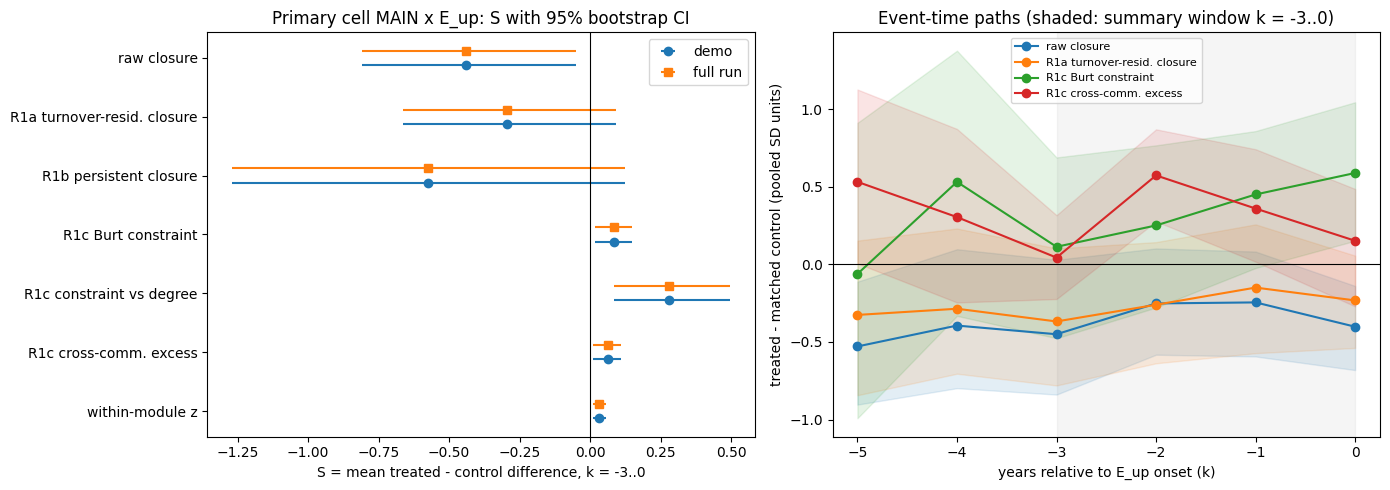

In [16]:
ref = data["metadata"]["reference_full_run"]
show = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "wmz"]
nice = {"closure": "raw closure", "closure_resT": "R1a turnover-resid. closure", "closure_persist": "R1b persistent closure",
        "constraint": "R1c Burt constraint", "cdeg_diag": "R1c constraint vs degree", "xc_excess": "R1c cross-comm. excess",
        "wmz": "within-module z"}
tab = []
for c in show:
    st = primary["rows"][c]["primary"]
    r = ref["S"].get(c, {})
    tab.append(dict(indicator=nice[c], S_demo=st["S"], ci_demo=f"[{st['ci'][0]:.3f}, {st['ci'][1]:.3f}]",
                    S_full=r.get("S"), ci_full=f"[{r['ci'][0]:.3f}, {r['ci'][1]:.3f}]" if r else "",
                    abs_dS=abs(st["S"] - r["S"]) if r else np.nan, p_holm=fam.get(c, {}).get("p_holm", np.nan)))
tab = pd.DataFrame(tab)
print(f"Primary cell {primary['cell']}: onsets {primary['n_onsets']} (full run {ref['n_onsets']}), "
      f"matched {primary['n_matched']} (full run {ref['n_matched']}); bootstrap B = {B}")
print(f"VERDICT demo = {v['verdict']} | full run = {ref['verdict']}")
flag_cmp = pd.DataFrame({"demo": {k: v["flags"][k] for k in ref["verdict_flags"]}, "full_run": ref["verdict_flags"]})
display(tab.round(4))
display(flag_cmp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for i, c in enumerate(show):
    st = primary["rows"][c]["primary"]
    ax.errorbar(st["S"], i + 0.12, xerr=[[st["S"] - st["ci"][0]], [st["ci"][1] - st["S"]]], fmt="o", color="C0",
                label="demo" if i == 0 else None)
    r = ref["S"][c]
    ax.errorbar(r["S"], i - 0.12, xerr=[[r["S"] - r["ci"][0]], [r["ci"][1] - r["S"]]], fmt="s", color="C1",
                label="full run" if i == 0 else None)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(show)))
ax.set_yticklabels([nice[c] for c in show])
ax.invert_yaxis()
ax.set_xlabel("S = mean treated - control difference, k = -3..0")
ax.set_title("Primary cell MAIN x E_up: S with 95% bootstrap CI")
ax.legend()

ax = axes[1]
ks = K.SPEC3["es_rel_years"]
for j, c in enumerate(["closure", "closure_resT", "constraint", "xc_excess"]):
    st = primary["rows"][c]
    d = np.array(st["diff_k"], float)
    lo = np.array([x[0] for x in st["ci_k"]], float)
    hi = np.array([x[1] for x in st["ci_k"]], float)
    sd = float(np.nanstd(ind[c].astype(float)))  # scale to pooled SD so rows share an axis
    ax.plot(ks, d / sd, "o-", color=f"C{j}", label=nice[c])
    ax.fill_between(ks, lo / sd, hi / sd, color=f"C{j}", alpha=0.12)
ax.axhline(0, color="k", lw=0.8)
ax.axvspan(-3, 0, color="grey", alpha=0.08)
ax.set_xlabel("years relative to E_up onset (k)")
ax.set_ylabel("treated - matched control (pooled SD units)")
ax.set_title("Event-time paths (shaded: summary window k = -3..0)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()